# 解剖神经网络 (Decoding Neural Networks)

## 课程导论
在第一节课中，我们认识了数据如何在张量（Tensor）中流动。今天，我们将拆解承载这些数据的“机器”——神经网络。我们将从微观的神经元构造讲起，理解它如何通过数学优化进行“学习”，并最终亲手写出你的第一个神经网络架构。

---

## 第一部分：神经网络的“齿轮” —— 结构与激活

神经网络不是一个黑盒，它是由一层层精密的数学运算嵌套而成的。

### 1. 层（Layers）
* **输入层 (Input Layer)**：接收外界信号。
* **隐藏层 (Hidden Layer)**：进行特征加工。神经网络的“深度”指的就是隐藏层的多少。
* **输出层 (Output Layer)**：给出最终答案。

### 2. 权重（Weights）与偏置（Bias）
每个神经元的本质都是一个线性方程：$y = w \cdot x + b$
* **权重 $w$**：代表信息的重要性（知识就存在这里）。
* **偏置 $b$**：调节神经元被激活的难易程度。

### 3. 激活函数（Activation Functions）—— 赋予“灵魂”
如果没有激活函数，再深的神经网络也只能处理直线。激活函数引入了**非线性**，让网络能处理复杂的曲线。
* **ReLU**：目前最主流的激活函数，让负信号归零。
* **Sigmoid/Tanh**：将信号压缩到特定区间。
* 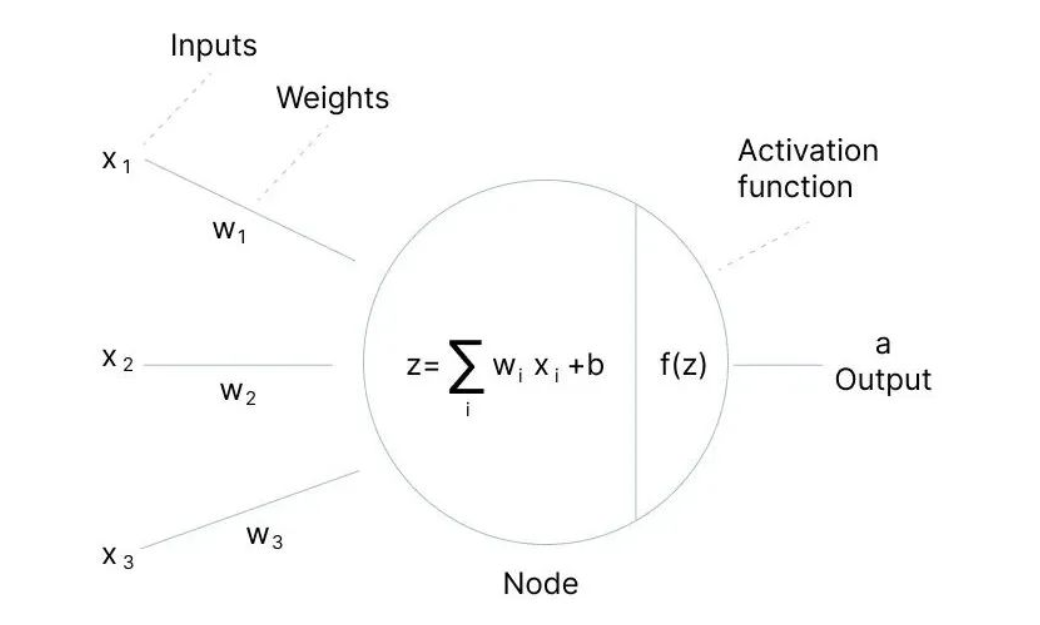
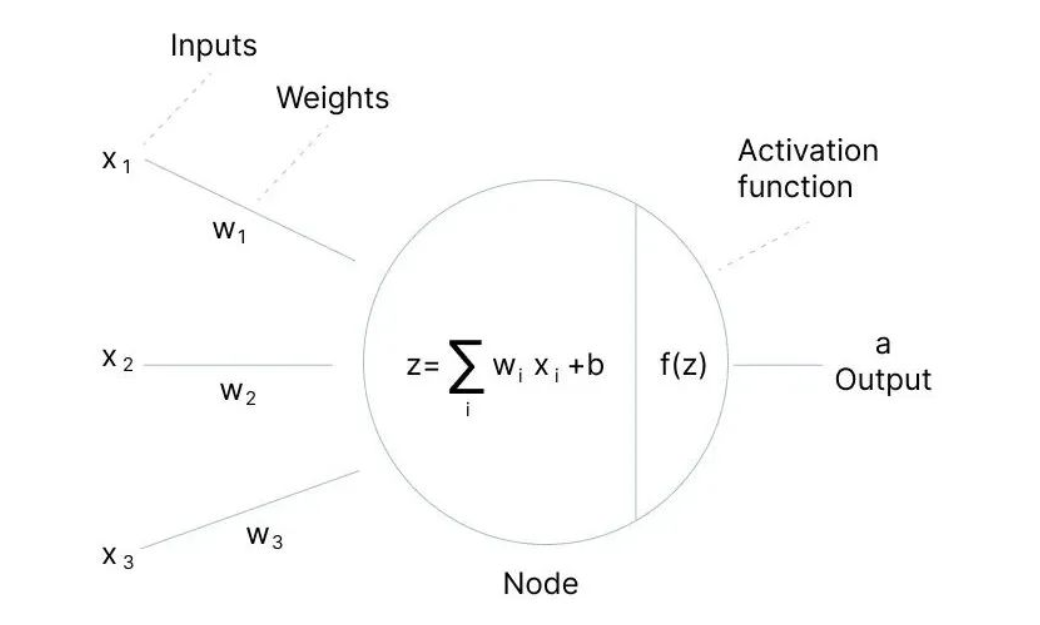

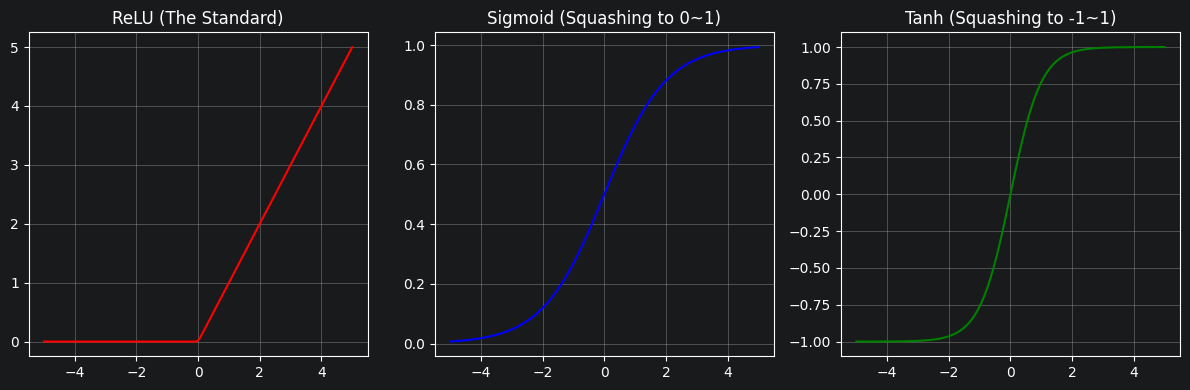

In [1]:
import torch
import matplotlib.pyplot as plt

# 准备一组从 -5 到 5 的数据
x = torch.linspace(-5, 5, 100)

# 定义三种常用的激活函数
relu = torch.nn.ReLU()
sigmoid = torch.nn.Sigmoid()
tanh = torch.nn.Tanh()

# 绘图对比
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x.numpy(), relu(x).numpy(), color='red')
plt.title("ReLU (The Standard)")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(x.numpy(), sigmoid(x).numpy(), color='blue')
plt.title("Sigmoid (Squashing to 0~1)")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(x.numpy(), tanh(x).numpy(), color='green')
plt.title("Tanh (Squashing to -1~1)")
plt.grid(True)

plt.tight_layout()
plt.show()

## 第二部分：优化与学习的本质 —— 进化逻辑

模型刚建立时，权重 $w$ 是随机的，它预测的结果也是一团糟。所谓的“学习”，就是让这些数字变准的过程。

### 1. 损失函数 (Loss Function)：测量“无知”的尺度
* **定义**：衡量预测值与真实值之间的“痛苦程度”。
* **MSE (均方误差)**：常用于回归问题，计算距离的平方。
    $$Loss = \frac{1}{n} \sum (y_{pred} - y_{true})^2$$
* **MAE (平均绝对误差)**：常用于回归问题，计算距离的绝对值。
    $$Loss = \frac{1}{n} \sum |y_{pred} - y_{true}|$$


### 2. 梯度下降 (Gradient Descent)：走下山谷的路径
* 想象你在浓雾笼罩的山顶，你要下山（减小误差）。
* **梯度**：指向上坡最快的方向。
* **更新规则**：我们要往梯度的**反方向**走，这就是权重更新。
    $$W_{new} = W_{old} - \eta \times \text{Gradient}$$
    其中 $\eta$ (Eta) 是 **学习率 (Learning Rate)**，决定了我们每一步跨多大。

### 3. 优化器 (Optimizer) —— 步法的艺术
* **SGD**：老老实实每一步都算的梯度下降。
* **Adam**：目前最智能、自适应的学习步法，是工程中的首选。

### 4. 关键术语
* **Epoch**：把整个数据集完整的训练（看）一遍。
* **Batch Size**：一次性喂给机器多少数据。

In [ ]:
x = 6
eta = 0.05
df =2*x -2

x = x - eta*df

6 - 0.05*10 =5.5



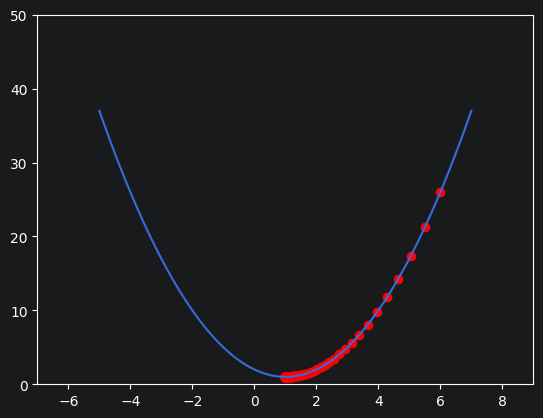

all_x[-1]: 1.0000000000000009
all_y[-1]: 1.0


In [1]:
# 梯度下降
import matplotlib.pyplot as plt
import numpy as np

# 初始算法开始之前的坐标
# cur_x 和 cur_y
cur_x = 6
cur_y = (cur_x-1)**2 + 1
# 设置学习率 eta 为 0.05
eta = 0.05
# 变量 iter 用于存储迭代次数
# 这次我们迭代 1000 次
# 所以给它赋值 1000
iter = 1000
# 变量 cur_df 用于存储
# 当前位置的导数
# 一开始我给它赋值为 None
# 每一轮循环的时候为它更新值
cur_df = None

# all_x 用于存储
# 算法进行时所有点的横坐标
all_x = []
# all_y 用于存储
# 算法进行时所有点的纵坐标
all_y = []

# 把最一开始的坐标存储到
# all_x 和 all_y 中
all_x.append(cur_x)
all_y.append(cur_y)

# 循环结束也就意味着算法的结束
for i in range(iter):
    # 每一次迭代之前先计算
    # 当前位置的梯度 cur_df
    # cur 是英文单词 current
    cur_df = 2*cur_x - 2
    # 更新 cur_x 到下一个位置
    cur_x = cur_x - eta*cur_df
    # 更新下一个 cur_x 对应的 cur_y
    cur_y = (cur_x-1)**2 + 1

    # 其实 cur_y 并没有起到实际的计算作用
    # 在这里计算 cur_y 只是为了将每一次的
    # 点的坐标存储到 all_x 和 all_y 中
    # all_x 存储了二维平面上所有点的横坐标
    # all_y 存储了二维平面上所欲点的纵坐标
    # 使用 list 的 append 方法添加元素
    all_x.append(cur_x)
    all_y.append(cur_y)

# 这里的 x, y 值为了绘制二次函数
# 的那根曲线用的，和算法没有关系
# linspace 将会从区间 [-5, 7] 中
# 等距离分割出 100 个点并返回一个
# np.array 类型的对象给 x
x = np.linspace(-5, 7, 100)
# 计算出 x 中每一个横坐标对应的纵坐标
y = (x-1)**2 + 1
# plot 函数会把传入的 x, y
# 组成的每一个点依次连接成一个平滑的曲线
# 这样就是我们看到的二次函数的曲线了
plt.plot(x, y)
# axis 函数用来指定坐标系的横轴纵轴的范围
# 这样就表示了
# 横轴为 [-7, 9]
# 纵轴为 [0, 50]
plt.axis([-7, 9, 0, 50])
# scatter 函数是用来绘制散点图的
# scatter 和 plot 函数不同
# scatter 并不会将每个点依次连接
# 而是直接将它们以点的形式绘制出来
plt.scatter(np.array(all_x), np.array(all_y), color='red')
plt.show()
print("all_x[-1]:", all_x[-1])
print("all_y[-1]:", all_y[-1])

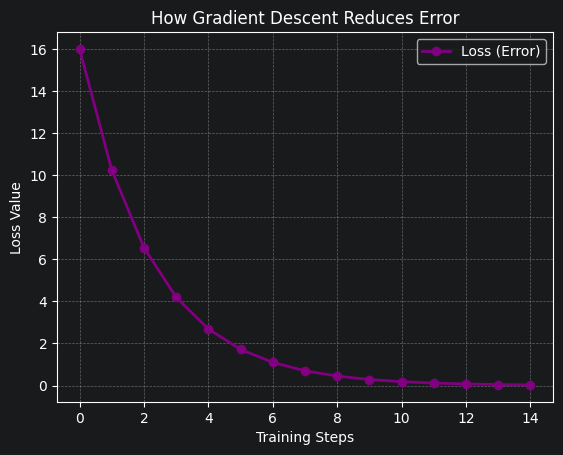

In [2]:
# 假设 Loss 函数是 L = w^2，我们的目标是找到 w=0
w = torch.tensor([4.0], requires_grad=True) # 初始权重设为 4
lr = 0.1 # 学习率

history_w = []
history_loss = []

for i in range(15):
    loss = w**2  # 损失函数
    history_w.append(w.item())
    history_loss.append(loss.item())

    loss.backward() # 反向传播，计算梯度

    with torch.no_grad():
        w -= lr * w.grad # 沿着梯度的反方向更新权值

    w.grad.zero_() # 清空梯度，准备下次计算

# 可视化
plt.plot(history_loss, 'o-', label='Loss (Error)', color='purple', linewidth=2)
plt.xlabel("Training Steps")
plt.ylabel("Loss Value")
plt.title("How Gradient Descent Reduces Error")
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

## 第三部分：动手建立第一个网络 —— 组装实战

现在我们将所有零件组装起来。
任务：我们让一个简单的 2 层神经网络去学习一段带有噪声的正弦波（Sine Wave）。

**网络设计：**
1.  **输入层**：1 个特征（x）。
2.  **隐藏层**：16 个神经元，使用 ReLU 激活特征。
3.  **输出层**：1 个预测结果（y）。

Epoch 0: Loss = 0.7307
Epoch 20: Loss = 0.3610
Epoch 40: Loss = 0.1646
Epoch 60: Loss = 0.0559
Epoch 80: Loss = 0.0283
Epoch 100: Loss = 0.0224


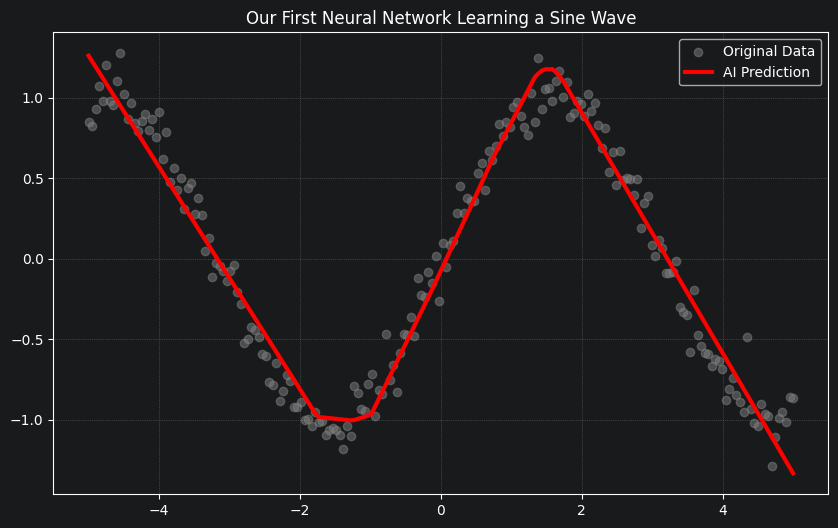

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. 制造一些带有噪声的数据
x_np = np.linspace(-5, 5, 200)
y_np = np.sin(x_np) + 0.1 * np.random.randn(200)

# 转换成 PyTorch 需要的二维张量格式 [200, 1]
x_train = torch.FloatTensor(x_np).view(-1, 1)
y_train = torch.FloatTensor(y_np).view(-1, 1)

# 2. 定义神经网络架构 (nn.Sequential 是组装积木最快的方式)
model = nn.Sequential(
    nn.Linear(1, 16),  # 第1层：线性层，输入1维，输出16维
    nn.ReLU(),         # 激活函数层
    nn.Linear(16, 1)   # 第2层：输出层，将16维特征压缩回1维预测值
)

# 3. 设置损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. 训练循环 (Epoch = 100)
for epoch in range(101):
    # 前向传播：让模型猜一次
    y_pred = model(x_train)

    # 计算误差
    loss = criterion(y_pred, y_train)

    # 优化三部曲：
    optimizer.zero_grad() # 1. 抹掉旧梯度
    loss.backward()       # 2. 算新梯度 (反向传播)
    optimizer.step()      # 3. 走一步 (更新权重)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

# 5. 结果可视化
plt.figure(figsize=(10, 6))
plt.scatter(x_np, y_np, label='Original Data', color='gray', alpha=0.5)
plt.plot(x_np, model(x_train).detach().numpy(), color='red', label='AI Prediction', linewidth=3)
plt.legend()
plt.title("Our First Neural Network Learning a Sine Wave")
plt.grid(True, linestyle=':')
plt.show()